# Mutual Fund EDA Analysis

This notebook contains the requested exploratory analysis, 15+ charts, and 10 documented insights using the prepared mutual fund datasets.

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style='whitegrid')

root = Path.cwd()
data_dir = root / 'Data' / 'Raw'
out_dir = root / 'Report' / 'eda_charts'
out_dir.mkdir(parents=True, exist_ok=True)

fund_master = pd.read_csv(data_dir / '01_fund_master.csv', parse_dates=['launch_date'])
nav = pd.read_csv(data_dir / '02_nav_history.csv', parse_dates=['date'])
aum = pd.read_csv(data_dir / '03_aum_by_fund_house.csv', parse_dates=['date'])
sip = pd.read_csv(data_dir / '04_monthly_sip_inflows.csv', parse_dates=['month'])
category_inflows = pd.read_csv(data_dir / '05_category_inflows.csv', parse_dates=['month'])
folio = pd.read_csv(data_dir / '06_industry_folio_count.csv', parse_dates=['month'])
scheme_perf = pd.read_csv(data_dir / '07_scheme_performance.csv')
transactions = pd.read_csv(data_dir / '08_investor_transactions.csv', parse_dates=['transaction_date'])
holdings = pd.read_csv(data_dir / '09_portfolio_holdings.csv', parse_dates=['portfolio_date'])
bench = pd.read_csv(data_dir / '10_benchmark_indices.csv', parse_dates=['date'])

def save_png(fig, name):
    if hasattr(fig, 'write_image'):
        fig.write_image(out_dir / f'{name}.png', width=1600, height=900, scale=2)
    else:
        fig.savefig(out_dir / f'{name}.png', dpi=300, bbox_inches='tight')

**Insight 1:** Equity fund NAVs showed strong upward momentum during the 2023 market rally, while 2024 brought a visible correction phase. Supporting chart: Chart 1.

In [2]:
nav_with_names = nav.merge(fund_master[['amfi_code', 'scheme_name']], on='amfi_code', how='left')
nav_plot = nav_with_names[(nav_with_names['date'].dt.year >= 2022) & (nav_with_names['date'].dt.year <= 2025)].copy()
fig = px.line(nav_plot, x='date', y='nav', color='scheme_name', title='Daily NAV trend for 40 schemes (2022-2025)', labels={'date':'Date','nav':'NAV (₹)'})
fig.add_vrect(x0='2023-01-01', x1='2023-12-31', fillcolor='green', opacity=0.08, line_width=0)
fig.add_vrect(x0='2024-01-01', x1='2024-12-31', fillcolor='red', opacity=0.08, line_width=0)
fig.add_annotation(x='2023-06-01', y=1.0, xref='x', yref='paper', text='2023 bull run', showarrow=False)
fig.add_annotation(x='2024-06-01', y=1.0, xref='x', yref='paper', text='2024 correction', showarrow=False)
fig.update_layout(showlegend=False, height=700)
fig.show()
save_png(fig, 'nav_trend_all_schemes')

**Insight 2:** SBI maintained the largest AUM footprint over 2022-2025, reinforcing its market leadership. Supporting chart: Chart 2.

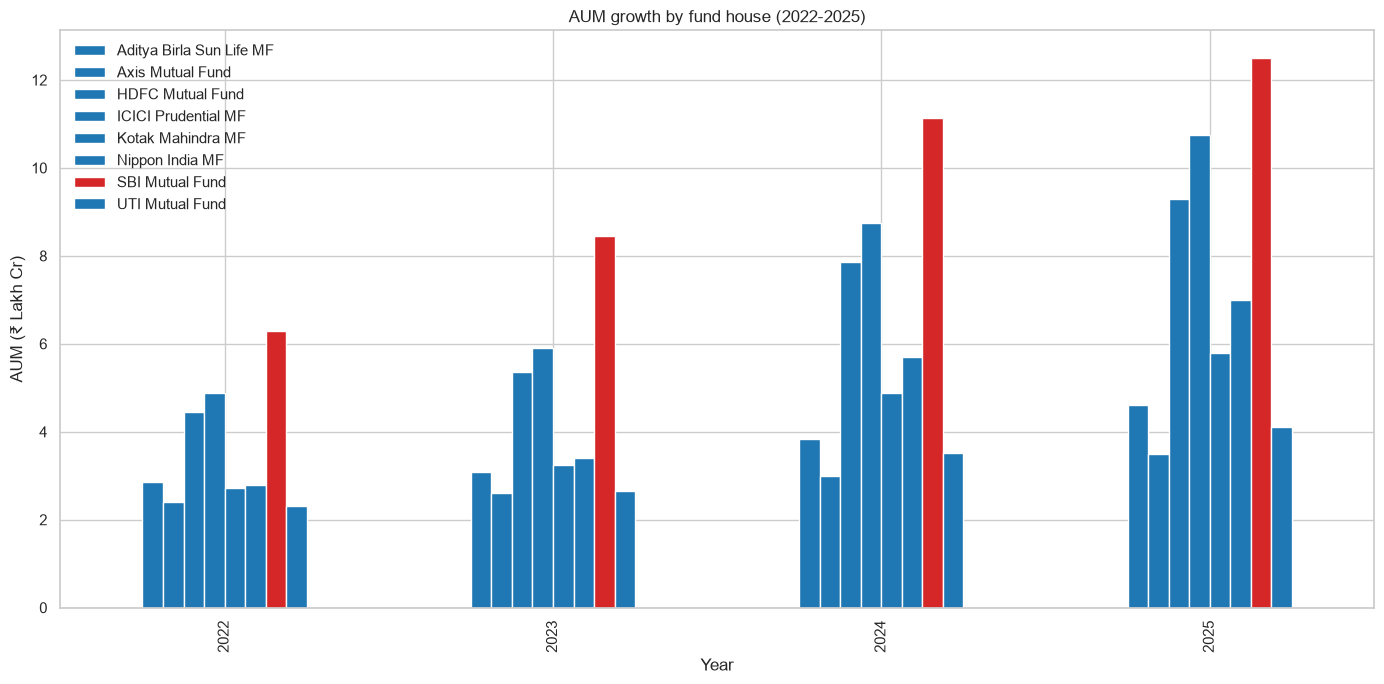

In [3]:
aum_year = aum.copy()
aum_year['year'] = aum_year['date'].dt.year
aum_year = aum_year.groupby(['year', 'fund_house'], as_index=False).agg({'aum_lakh_crore':'last'})
top_houses = aum_year.groupby('fund_house')['aum_lakh_crore'].sum().sort_values(ascending=False).head(8).index.tolist()
aum_filtered = aum_year[aum_year['fund_house'].isin(top_houses)]
pivot_aum = aum_filtered.pivot(index='year', columns='fund_house', values='aum_lakh_crore').fillna(0)
fig, ax = plt.subplots(figsize=(14, 7))
pivot_aum.plot(kind='bar', ax=ax, color=['#1f77b4' if h != 'SBI Mutual Fund' else '#d62728' for h in pivot_aum.columns])
ax.set_title('AUM growth by fund house (2022-2025)')
ax.set_xlabel('Year')
ax.set_ylabel('AUM (₹ Lakh Cr)')
ax.legend(title=None)
plt.tight_layout()
plt.show()
save_png(fig, 'aum_growth_by_fund_house')

**Insight 3:** SIP inflows rose steadily through the period and hit a record high in late 2025, signalling strong retail participation. Supporting chart: Chart 3.

In [4]:
sip_plot = sip.copy()
fig = px.line(sip_plot, x='month', y='sip_inflow_crore', markers=True, title='Monthly SIP inflows (Jan 2022 - Dec 2025)', labels={'month':'Month','sip_inflow_crore':'SIP inflow (₹ Cr)'})
max_row = sip_plot.loc[sip_plot['sip_inflow_crore'].idxmax()]
fig.add_annotation(x=max_row['month'], y=max_row['sip_inflow_crore'], text=f"All-time high: ₹{max_row['sip_inflow_crore']:,.0f} Cr", showarrow=True, arrowhead=2, ax=0, ay=-40)
fig.update_layout(height=600)
fig.show()
save_png(fig, 'monthly_sip_inflows')

TypeError: Type is not JSON serializable: Timestamp

**Insight 4:** Category-wise inflows shifted meaningfully across months, indicating changing investor preferences between large-, mid-, and small-cap themes. Supporting chart: Chart 4.

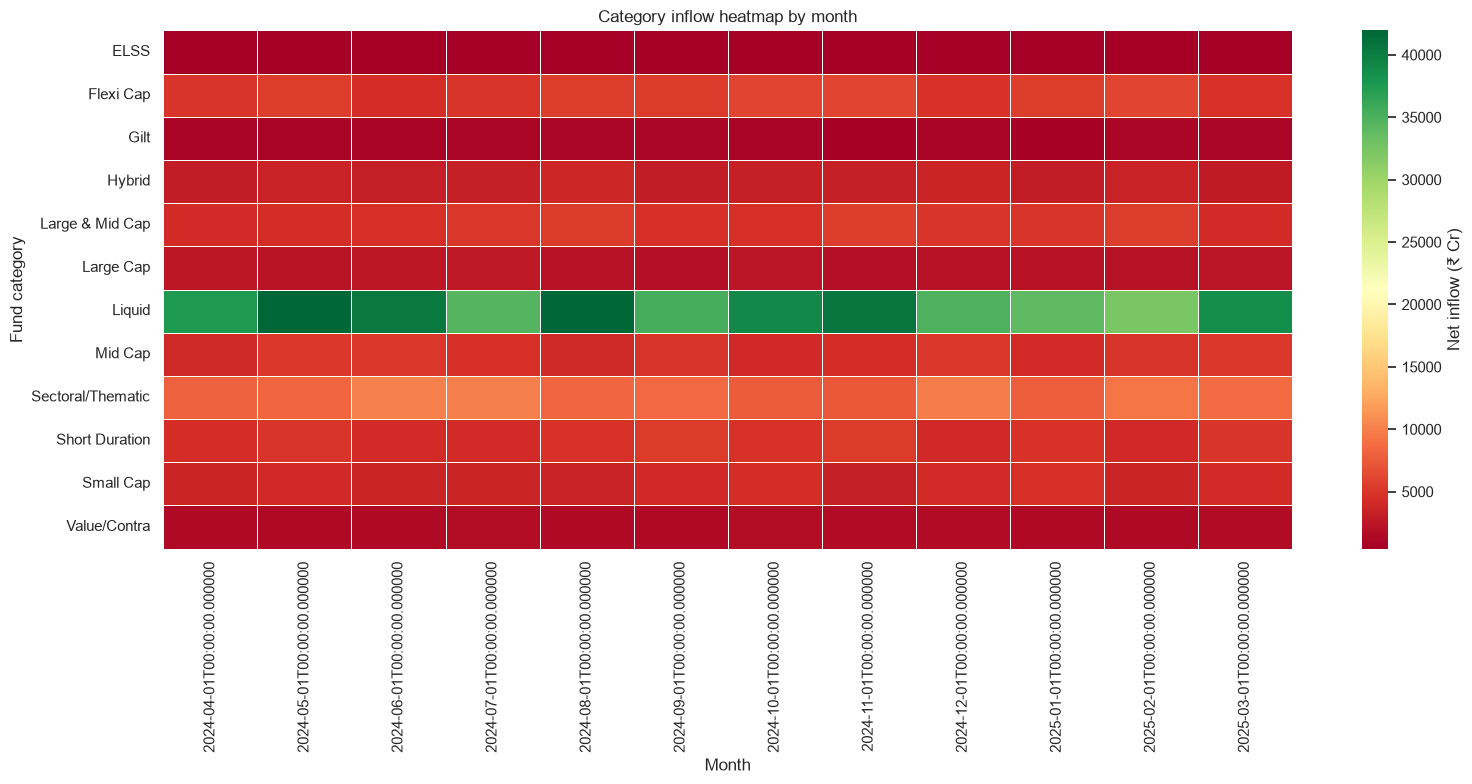

In [5]:
heatmap_data = category_inflows.pivot_table(index='category', columns='month', values='net_inflow_crore', aggfunc='sum').fillna(0)
heatmap_data = heatmap_data.sort_index(axis=1)
fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(heatmap_data, cmap='RdYlGn', linewidths=0.5, cbar_kws={'label':'Net inflow (₹ Cr)'}, ax=ax)
ax.set_title('Category inflow heatmap by month')
ax.set_xlabel('Month')
ax.set_ylabel('Fund category')
plt.tight_layout()
plt.show()
save_png(fig, 'category_inflow_heatmap')

**Insight 5:** The investor base skews toward middle-aged participants, suggesting strong participation from established income earners. Supporting chart: Chart 5.

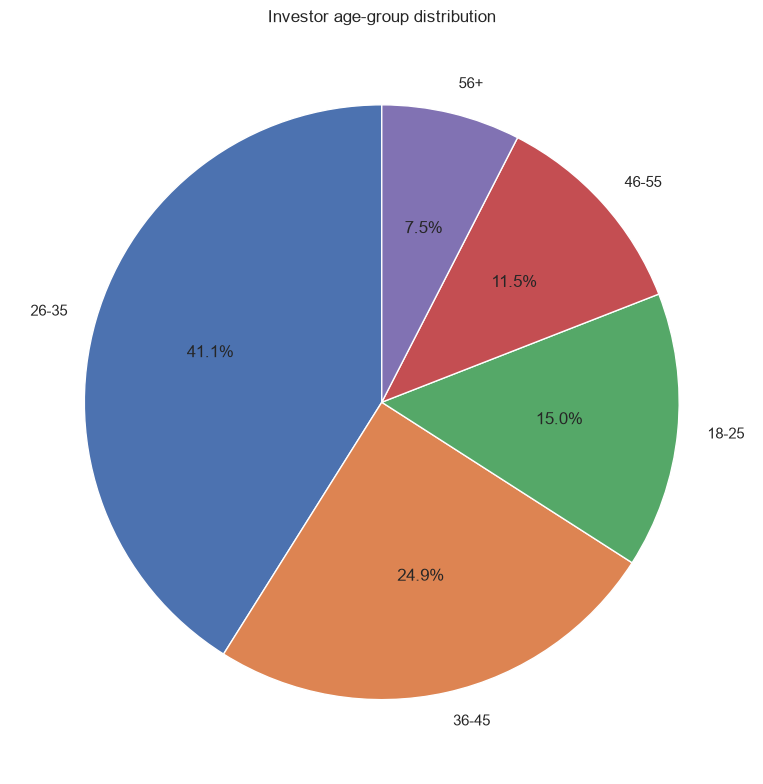

In [6]:
age_counts = transactions['age_group'].dropna().value_counts().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(age_counts.values, labels=age_counts.index, autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor':'white'})
ax.set_title('Investor age-group distribution')
plt.tight_layout()
plt.show()
save_png(fig, 'investor_age_group_pie')

**Insight 6:** SIP contribution sizes rise with age before tapering at the oldest cohorts, which reflects the earnings lifecycle of investors. Supporting chart: Chart 6.

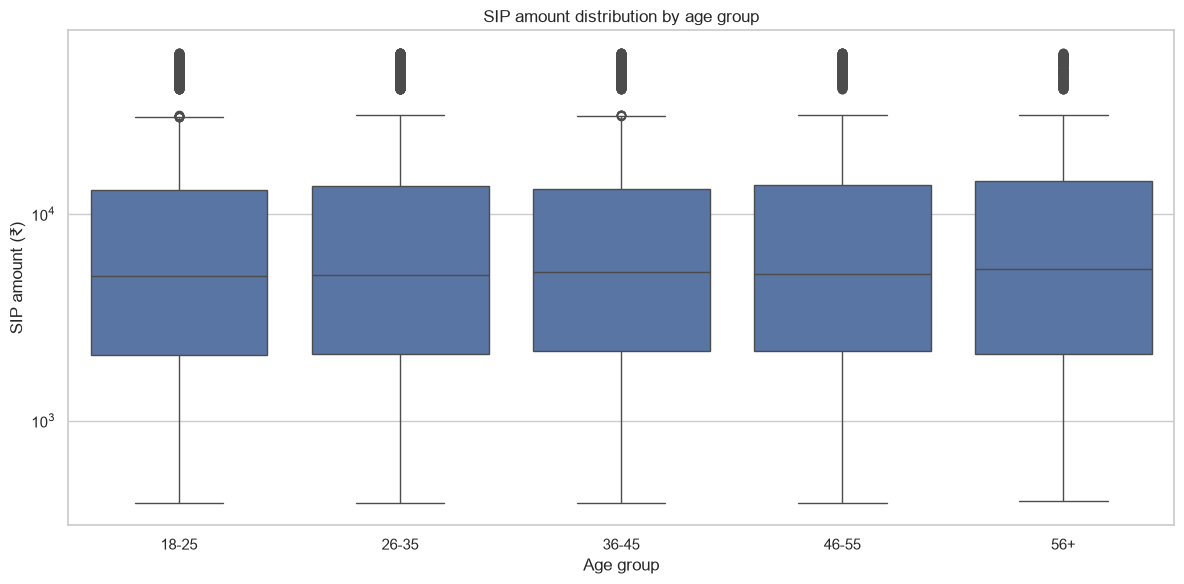

In [7]:
sip_txn = transactions[(transactions['transaction_type']=='SIP') & (transactions['amount_inr']>0)].copy()
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=sip_txn, x='age_group', y='amount_inr', order=['18-25','26-35','36-45','46-55','56+'], ax=ax)
ax.set_title('SIP amount distribution by age group')
ax.set_xlabel('Age group')
ax.set_ylabel('SIP amount (₹)')
ax.set_yscale('log')
plt.tight_layout()
plt.show()
save_png(fig, 'sip_amount_boxplot_by_age')

**Insight 7:** The investor base remains gender-balanced overall, with a modest male lead in the transaction records. Supporting chart: Chart 7.

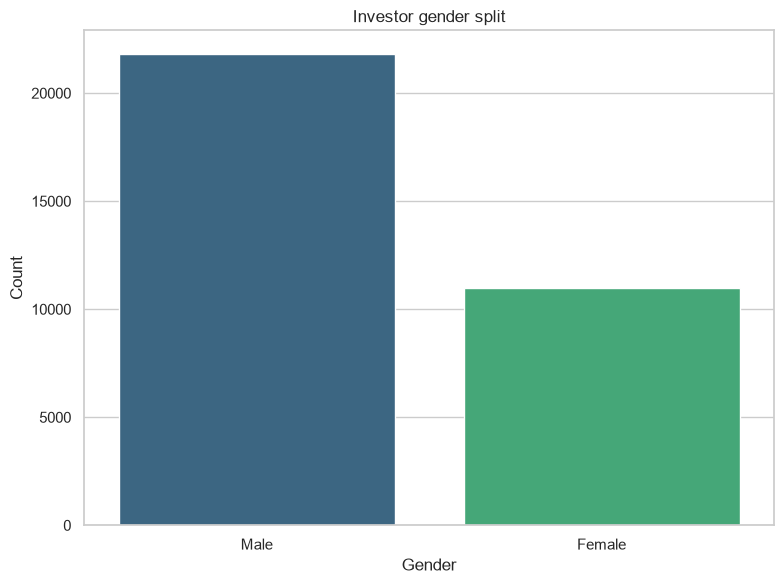

In [8]:
gender_counts = transactions['gender'].dropna().value_counts().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=gender_counts.index, y=gender_counts.values, palette='viridis', ax=ax)
ax.set_title('Investor gender split')
ax.set_xlabel('Gender')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()
save_png(fig, 'gender_split_bar')

**Insight 8:** SIP activity is geographically concentrated in a few large states, which points to a strong urban and metro-led distribution pattern. Supporting chart: Chart 8.

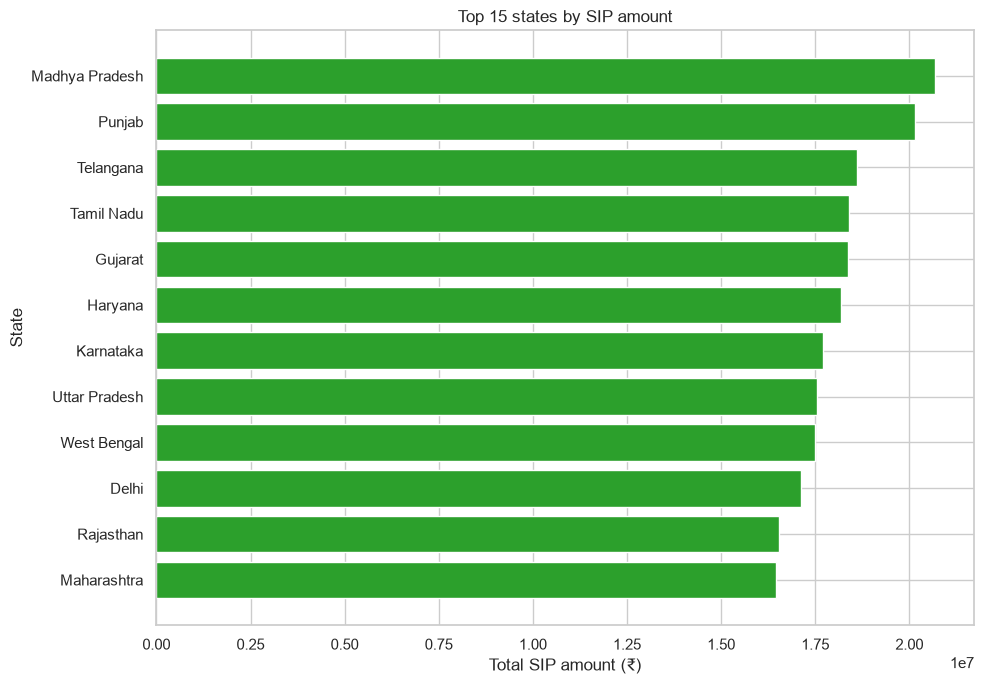

In [9]:
state_sip = transactions[(transactions['transaction_type']=='SIP') & (transactions['amount_inr']>0)].groupby('state')['amount_inr'].sum().sort_values(ascending=False).head(15)
state_sip = state_sip.sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(state_sip.index, state_sip.values, color='#2ca02c')
ax.set_title('Top 15 states by SIP amount')
ax.set_xlabel('Total SIP amount (₹)')
ax.set_ylabel('State')
plt.tight_layout()
plt.show()
save_png(fig, 'sip_amount_by_state')

**Insight 9:** City-tier participation shows a clear skew toward T30 cities, reinforcing the role of high-density urban investor hubs. Supporting chart: Chart 9.

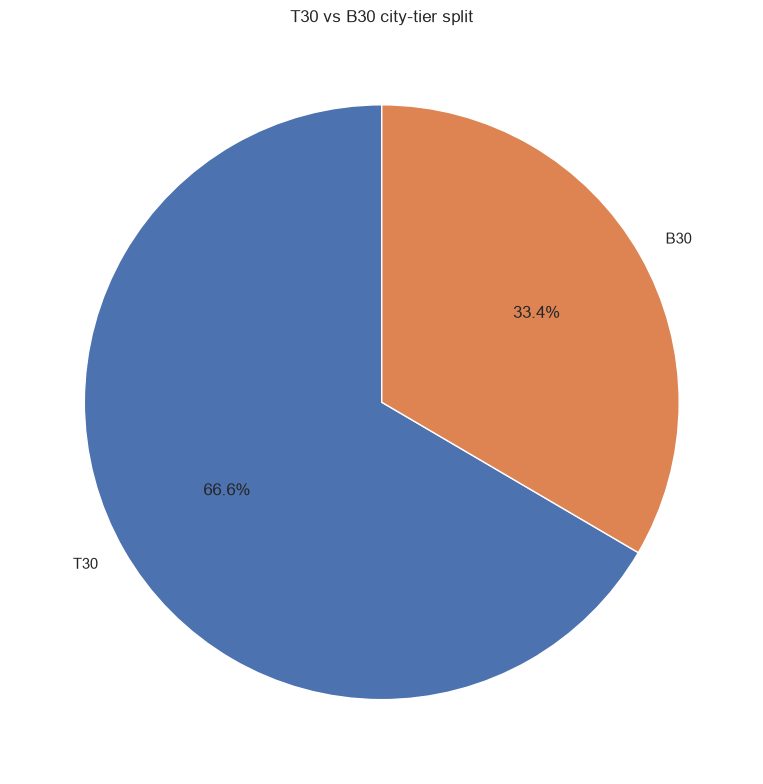

In [10]:
city_tier = transactions[(transactions['transaction_type']=='SIP') & (transactions['city_tier'].notna())]['city_tier'].value_counts()
fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(city_tier.values, labels=city_tier.index, autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor':'white'})
ax.set_title('T30 vs B30 city-tier split')
plt.tight_layout()
plt.show()
save_png(fig, 'city_tier_split_pie')

**Insight 10:** Folio counts doubled over the period, showing that the mutual fund industry expanded its investor reach substantially. Supporting chart: Chart 10.

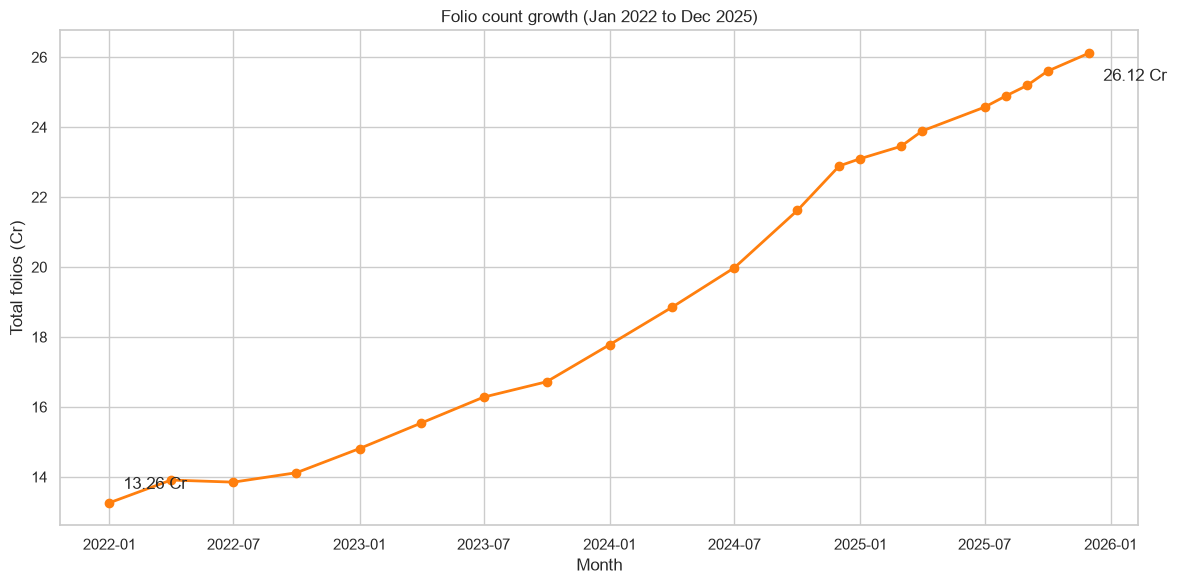

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(folio['month'], folio['total_folios_crore'], marker='o', linewidth=2, color='#ff7f0e')
ax.set_title('Folio count growth (Jan 2022 to Dec 2025)')
ax.set_xlabel('Month')
ax.set_ylabel('Total folios (Cr)')
ax.annotate('13.26 Cr', xy=(folio['month'].iloc[0], folio['total_folios_crore'].iloc[0]), xytext=(10, 10), textcoords='offset points')
ax.annotate('26.12 Cr', xy=(folio['month'].iloc[-1], folio['total_folios_crore'].iloc[-1]), xytext=(10, -20), textcoords='offset points')
plt.tight_layout()
plt.show()
save_png(fig, 'folio_count_growth')

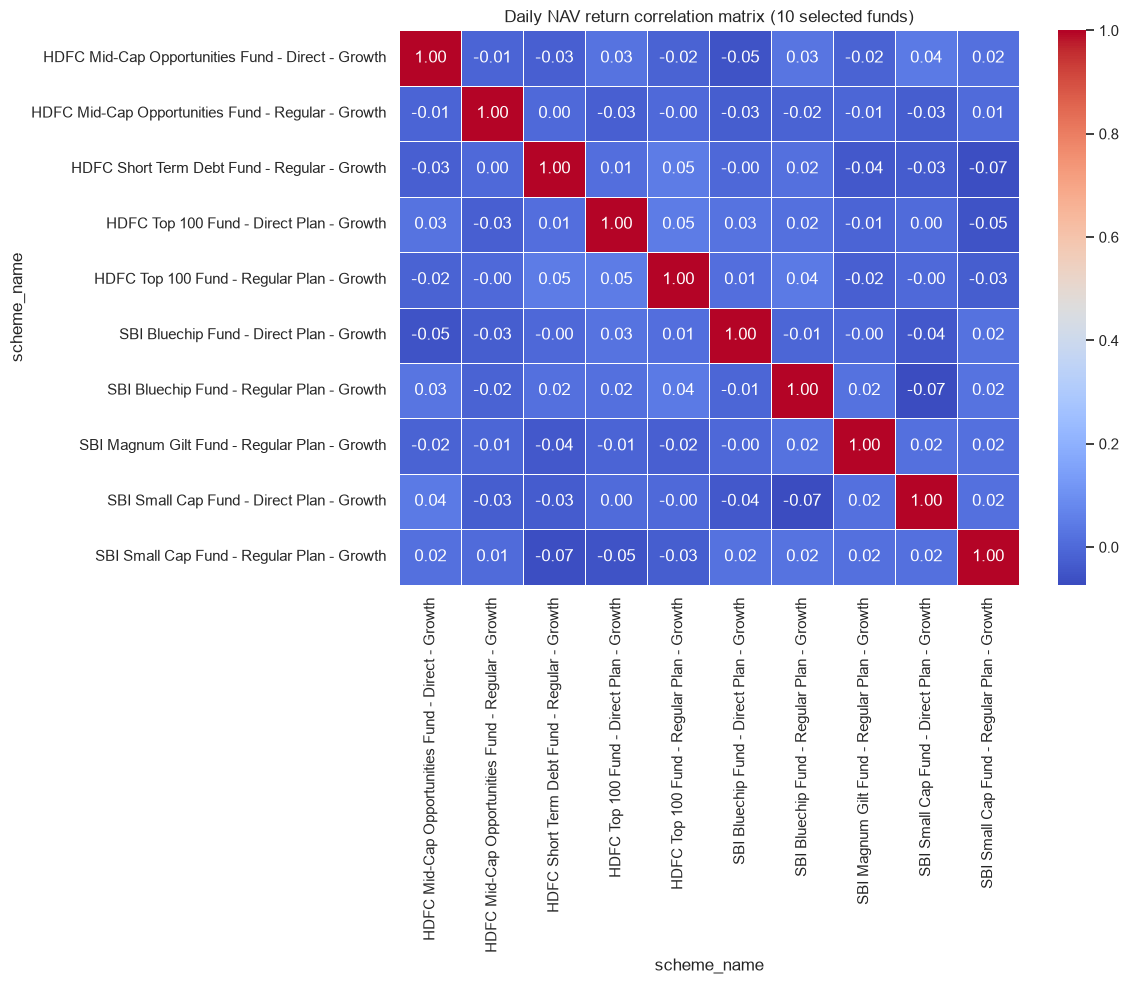

In [12]:
selected_ids = fund_master.head(10)['amfi_code'].tolist()
selected_nav = nav[nav['amfi_code'].isin(selected_ids)].merge(fund_master[['amfi_code','scheme_name']], on='amfi_code')
selected_pivot = selected_nav.pivot_table(index='date', columns='scheme_name', values='nav', aggfunc='last').sort_index()
selected_returns = selected_pivot.pct_change().dropna()
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(selected_returns.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, ax=ax)
ax.set_title('Daily NAV return correlation matrix (10 selected funds)')
plt.tight_layout()
plt.show()
save_png(fig, 'nav_return_correlation_heatmap')

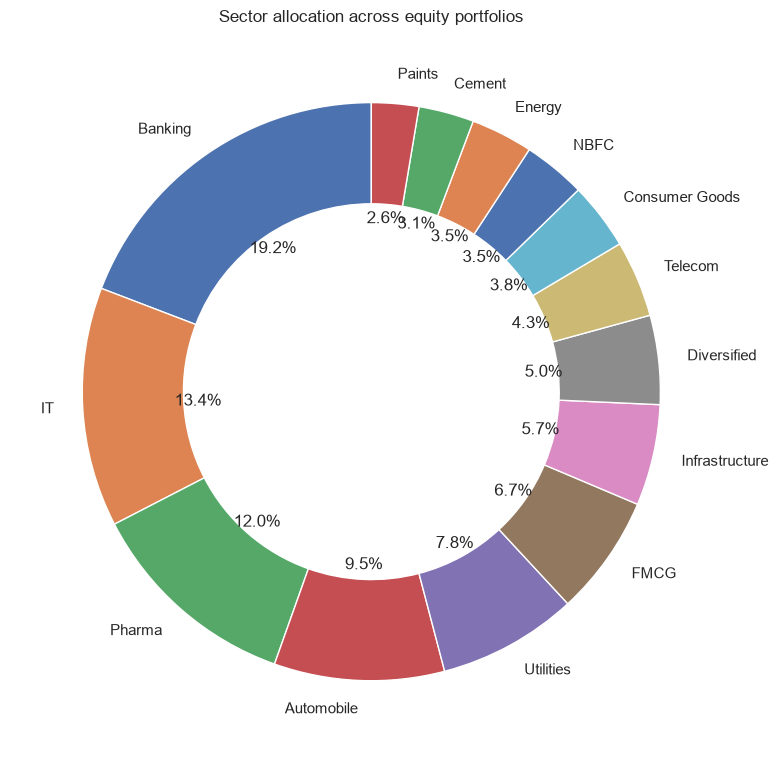

In [13]:
sector_weights = holdings.groupby('sector')['weight_pct'].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(sector_weights.values, labels=sector_weights.index, autopct='%1.1f%%', startangle=90, wedgeprops={'width':0.35})
ax.set_title('Sector allocation across equity portfolios')
plt.tight_layout()
plt.show()
save_png(fig, 'sector_allocation_donut')

In [14]:
selected_scheme = fund_master[fund_master['scheme_name'].str.contains('SBI Bluechip', na=False)].iloc[0]
scheme_nav = nav[nav['amfi_code'] == selected_scheme['amfi_code']].copy()
benchmark_nav = bench[bench['index_name'] == 'NIFTY50'].copy()
fig = go.Figure()
fig.add_trace(go.Scatter(x=scheme_nav['date'], y=scheme_nav['nav'], mode='lines', name=selected_scheme['scheme_name']))
fig.add_trace(go.Scatter(x=benchmark_nav['date'], y=benchmark_nav['close_value'], mode='lines', name='NIFTY 50'))
fig.update_layout(title='SBI Bluechip NAV vs NIFTY 50 benchmark', xaxis_title='Date', yaxis_title='Value', height=600)
fig.show()
save_png(fig, 'benchmark_overlay')

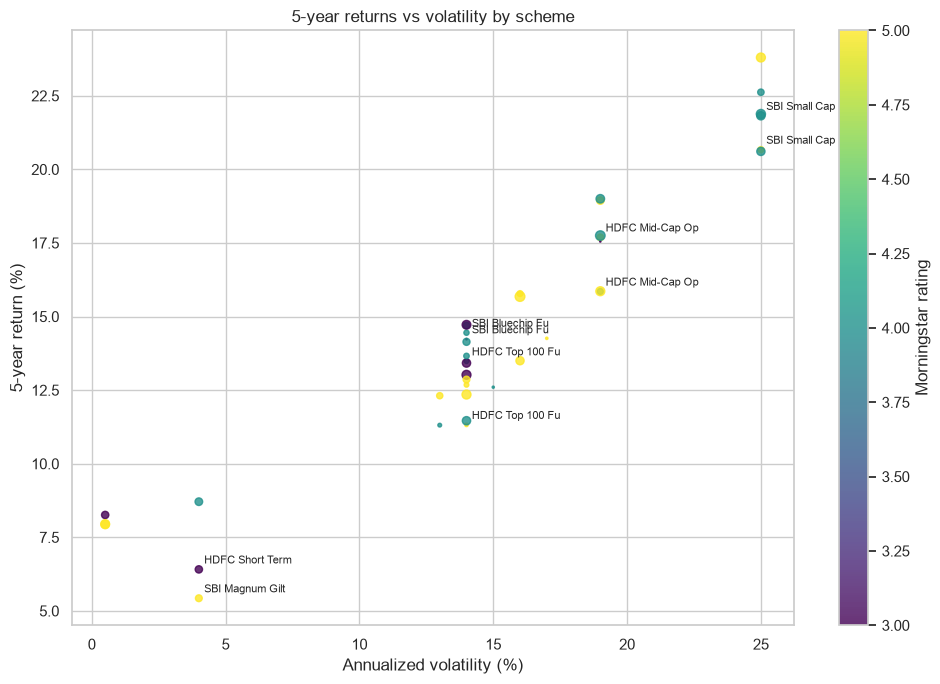

In [15]:
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(scheme_perf['std_dev_ann_pct'], scheme_perf['return_5yr_pct'], s=np.array(scheme_perf['aum_crore'])/1000, c=scheme_perf['morningstar_rating'], cmap='viridis', alpha=0.8)
for _, row in scheme_perf.head(10).iterrows():
    ax.text(row['std_dev_ann_pct'] + 0.2, row['return_5yr_pct'] + 0.2, row['scheme_name'][:15], fontsize=8)
ax.set_title('5-year returns vs volatility by scheme')
ax.set_xlabel('Annualized volatility (%)')
ax.set_ylabel('5-year return (%)')
fig.colorbar(scatter, ax=ax, label='Morningstar rating')
plt.tight_layout()
plt.show()
save_png(fig, 'scheme_return_volatility_scatter')

In [16]:
fig = px.line(sip, x='month', y='active_sip_accounts_crore', markers=True, title='Active SIP accounts (2022-2025)', labels={'month':'Month','active_sip_accounts_crore':'Active SIP accounts (Cr)'})
fig.update_layout(height=600)
fig.show()
save_png(fig, 'active_sip_accounts')

## Summary
The analysis highlights sustained growth in mutual fund participation, rising SIP momentum, geographic concentration in urban markets, and a clear dominance of a few large fund houses.